Project Overview
   
   This project analyzes product-level data to understand factors that influence return rates. The goal is to identify patterns between product price, discount rate, category, and customer behavior in order to better understand what drives product returns.



Data Loading

The dataset was loaded into a pandas DataFrame and inspected to understand its structure, including column types, missing values, and overall size. This step ensures the data is ready for analysis.

In [67]:
import pandas as pd

df = pd.read_csv('SalesProject.csv')

print(df.head())
print(df.info())

   Product_Price  Discount_Rate  Product_Rating  Number_of_Reviews  \
0     199.671415       0.177024        4.411071               62.0   
1     136.173570       0.041467        3.033534              201.0   
2     214.768854       0.276197        2.866881              479.0   
3     302.302986       0.094254        4.473473              252.0   
4     126.584663       0.411845        3.553082              671.0   

   Stock_Availability  Days_to_Deliver  Return_Rate  Category_ID  
0                 1.0              9.0     0.185116          5.0  
1                 1.0              3.0     0.384639         10.0  
2                 1.0             19.0     0.056410          4.0  
3                 1.0             11.0          NaN          7.0  
4                 1.0             14.0     0.672163          6.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------           

Data Cleaning

The dataset was cleaned by removing missing values to ensure consistency in the analysis. This step helps avoid bias or errors caused by incomplete records and ensures that all insights are based on complete data.

In [68]:
import pandas as pd

# check missing values
print(df.isnull().sum())

Product_Price         100
Discount_Rate         100
Product_Rating        100
Number_of_Reviews     100
Stock_Availability    100
Days_to_Deliver       100
Return_Rate           100
Category_ID           100
dtype: int64


In [69]:
df = df.dropna()  # simplest clean approach for portfolio 1

print(df.isnull().sum())
print(df.shape)

Product_Price         0
Discount_Rate         0
Product_Rating        0
Number_of_Reviews     0
Stock_Availability    0
Days_to_Deliver       0
Return_Rate           0
Category_ID           0
dtype: int64
(1314, 8)


Exploratory Data Analysis

Exploratory analysis was performed to understand relationships between variables. This included correlation analysis and grouped summaries to identify patterns between product attributes and return rates.

In [70]:
df.corr(numeric_only=True)['Return_Rate'].sort_values(ascending=False)

,Return_Rate
Return_Rate,1.000000
Category_ID,0.032148
Product_Price,0.031758
Discount_Rate,0.030919
Number_of_Reviews,0.029308
Product_Rating,0.018550
Days_to_Deliver,-0.001157
Stock_Availability,-0.006961


In [71]:
df.groupby('Category_ID')['Return_Rate'].mean().sort_values(ascending=False)

,Return_Rate
Category_ID,
10.0,0.348796
3.0,0.342177
8.0,0.333548
4.0,0.333134
7.0,0.331305
9.0,0.326438
1.0,0.324423
5.0,0.323909
6.0,0.323359


In [72]:
df.groupby(pd.cut(df['Product_Price'], bins=5))['Return_Rate'].mean()

/tmp/ipykernel_1319/3208263562.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df['Product_Price'], bins=5))['Return_Rate'].mean()


,Return_Rate
Product_Price,
"(4.47, 111.055]",0.323739
"(111.055, 217.109]",0.328995
"(217.109, 323.164]",0.327867
"(323.164, 429.219]",0.369306
"(429.219, 535.273]",0.403570


In [73]:
df.groupby(pd.cut(df['Discount_Rate'], bins=5))['Return_Rate'].mean()

/tmp/ipykernel_1319/2941045549.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df['Discount_Rate'], bins=5))['Return_Rate'].mean()


,Return_Rate
Discount_Rate,
"(0.00568, 0.165]",0.330123
"(0.165, 0.324]",0.317012
"(0.324, 0.483]",0.345760
"(0.483, 0.641]",0.337943
"(0.641, 0.8]",0.299271


Visualizations

Visualizations were used to better understand patterns in the data. Scatter plots and grouped bar charts were created to explore relationships between price, discount rate, and return behavior.

In [74]:
import matplotlib.pyplot as plt

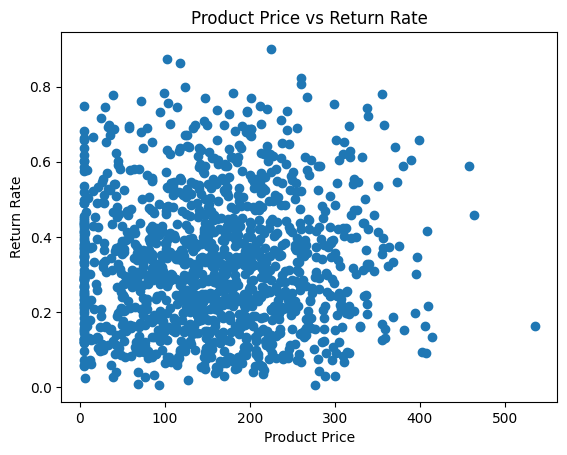

In [75]:
plt.figure()

plt.scatter(df['Product_Price'], df['Return_Rate'])
plt.xlabel('Product Price')
plt.ylabel('Return Rate')
plt.title('Product Price vs Return Rate')

plt.show()

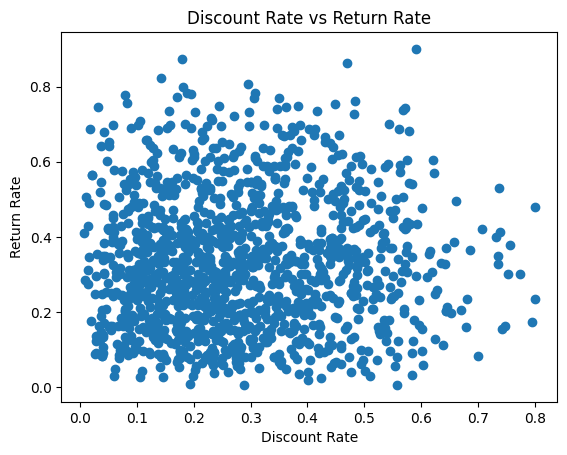

In [76]:
plt.figure()

plt.scatter(df['Discount_Rate'], df['Return_Rate'])
plt.xlabel('Discount Rate')
plt.ylabel('Return Rate')
plt.title('Discount Rate vs Return Rate')

plt.show()

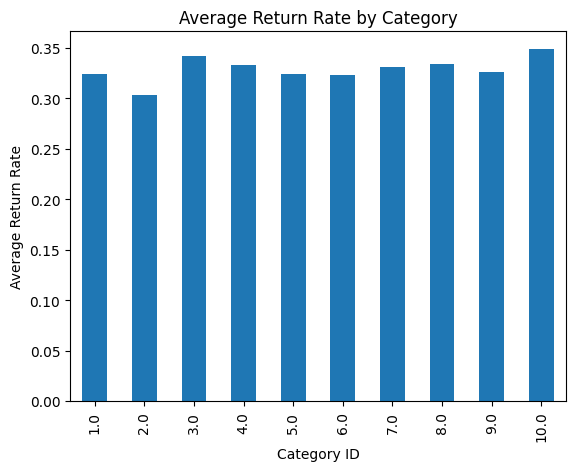

In [77]:
category_returns = df.groupby('Category_ID')['Return_Rate'].mean()

plt.figure()

category_returns.plot(kind='bar')
plt.xlabel('Category ID')
plt.ylabel('Average Return Rate')
plt.title('Average Return Rate by Category')

plt.show()

/tmp/ipykernel_1319/3763773442.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_band_returns = df.groupby('Price_Band')['Return_Rate'].mean()


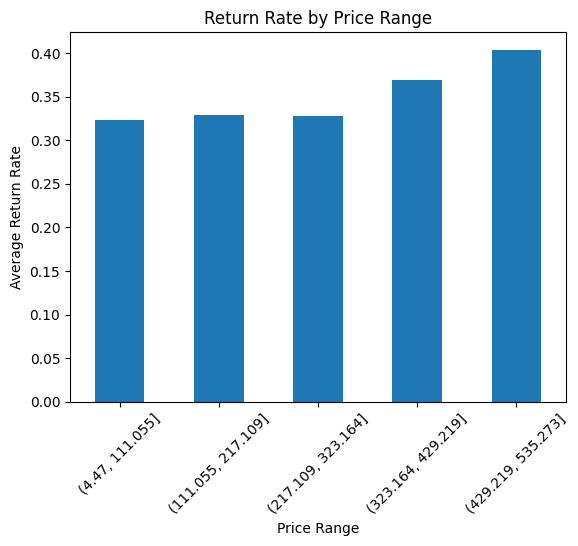

In [78]:
df['Price_Band'] = pd.cut(df['Product_Price'], bins=5)

price_band_returns = df.groupby('Price_Band')['Return_Rate'].mean()

plt.figure()

price_band_returns.plot(kind='bar')
plt.xlabel('Price Range')
plt.ylabel('Average Return Rate')
plt.title('Return Rate by Price Range')

plt.xticks(rotation=45)
plt.show()

Key Insights

The analysis shows that no single variable strongly predicts return rates. However, grouped analysis reveals clearer patterns, particularly in price ranges and discount levels. Higher-priced products show more variability in returns, while discount rate shows a non-linear relationship with return behavior. Category-level differences exist but are relatively small.

Overall, the findings suggest that product return behavior is influenced by a combination of factors rather than a single driver. This highlights the importance of using segmented and multi-variable analysis when studying customer behavior.